# 4- Trying the models

Classifier: SVM (linear), RF

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
import cognitive_models.gaze_utils as cwgaze
from importlib import reload
reload(cwgaze)
reload(cwpupil)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = list(range(1, 48)) # Participants 1 to 10
PARTICIPANTS.remove(6) # Bad data
EXPERIMENTS = [1,2,3,4]

### A. Getting all the needed features

In [25]:
# 1- Load all required data
all_eye_data = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print(f"Loaded eye-tracking data for {len(PARTICIPANTS)} participants and {len(EXPERIMENTS)} experiments. Total records: {len(all_eye_data)}")

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4099 records at 120 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3437 records at 120 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 8754 records at 120 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4637 records at 120 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 5082 records at 120 Hz
Final merged and resampled dataset has 2505 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3557 records at 120 Hz
Final merged and resampled dataset has 1769 records at 60 Hz
Ther

In [3]:
# Lets check integrity of the data
all_eye_data.columns
all_eye_data.groupby(['subject_id', 'task_id'])['cl_class'].value_counts().sort_index().head()

subject_id  task_id  cl_class
1           1        low         2028
            2        medium      1709
            3        high        4285
            4        medium      2290
2           1        low         2505
Name: count, dtype: int64

In [28]:
import tqdm

reload(cwfeat)
all_eye_data_grouped = all_eye_data.groupby(['subject_id', 'task_id'])
# Extract all window features
Fs = 60
WINDOW_N = 600 # 10 seconds at 60Hz
WINDOW_STEP = 60
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

skipped_windows = None
skip_window_counter = 0

features_df = pd.DataFrame()
for (subject_id, task_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_colet_data(window_df, verbose=False)
        if window_preprocess_df['low_confidence_percentage'].iloc[0] > 30:
            t_start = window_preprocess_df['timestamp_sec'].min()
            t_end = window_preprocess_df['timestamp_sec'].max()
            #print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {window_preprocess_df['low_confidence_percentage'].iloc[0]:.2f}%")
            skip_window_counter += 1
            window_preprocess_df['skip_id'] = skip_window_counter
            skipped_windows = pd.concat([skipped_windows, window_preprocess_df], ignore_index=True) if skipped_windows is not None else window_preprocess_df
            continue

        # Extract features
        try:
            features = cwfeat.extract_window_features(
                window_preprocess_df, 
                window_gaze_df, 
                window_pupil_df, 
                window_gaps_df, 
                ivt_threshold=45, 
                min_fixation_duration=55, 
                verbose=False
            )
        except Exception as e:
            print(f"Error extracting features for window in subject {subject_id}, task {task_id}: {e}")
            continue
        features['bad_samples_ratio'] = window_preprocess_df['low_confidence_percentage'].mean()
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['mean_score'] = window_preprocess_df['mean_score'].iloc[0]
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)
    # if subject_id > 5:
    #     break

print(f"Extracted features for {len(features_df)} windows.")
print(f"Skipped {skip_window_counter} windows due to low confidence percentage.")

Extracting features: 100%|██████████| 184/184 [14:55<00:00,  4.87s/it]

Extracted features for 6303 windows.
Skipped 581 windows due to low confidence percentage.


In [29]:
# Check what is the issue with the NaNs
print("Number of windows with NaN values:", features_df.isna().any(axis=1).sum())
features_df[features_df.isna().any(axis=1)].head()

Number of windows with NaN values: 8


,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id,mean_score
296,3,3133.9600,6334.60,1016.87,1.473930,NaN,2819.596343,3,68.112232,151.041981,...,72.662845,4,266.72,100.02,3.613735,0.001509,25.166667,3,3,45.000000
1403,4,2446.3225,3684.07,1416.95,0.198801,-4.697849,1127.691925,3,46.557093,104.208864,...,16.670000,0,0.00,0.00,4.406464,0.001423,8.000000,12,4,49.171429
1404,4,2446.3225,3684.07,416.75,-1.410833,2.153521,1427.817370,3,46.557093,104.208864,...,16.670000,0,0.00,0.00,4.106024,0.001557,8.000000,12,4,49.171429
1405,4,2450.4900,3283.99,233.38,-1.986549,3.956461,1479.722701,3,46.557093,104.208864,...,19.248858,0,0.00,0.00,4.005877,0.001663,8.500000,12,4,49.171429
1406,4,2450.4900,3283.99,1233.58,-0.741022,-1.653764,948.775409,3,46.557093,104.208864,...,19.248858,0,0.00,0.00,4.206170,0.001776,8.500000,12,4,49.171429


In [31]:
from sklearn import preprocessing
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True) # Drop rows with NaNs for now

# Apply thresholding to the mean NASA RTX score for classes
features_df_transformed["cl_class"] = features_df_transformed["mean_score"].apply(lambda x: "high" if x > 49 else ("low" if x < 30 else "medium"))
features_df_transformed.drop(columns=['mean_score'], inplace=True)
feature_cols = [col for col in features_df_transformed.columns if col not in ['subject_id', 'task_id', 'cl_class']]

features_df_transformed.describe()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_kurt,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id
count,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,...,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000,6295.000000
mean,20.393646,442.611280,1719.019933,74.362235,1.918437,4.325812,448.973696,19.647498,51.286159,287.857757,...,4.280032,50.232658,2.017474,112.341765,79.785612,4.471259,0.004259,6.071141,24.800159,2.762510
std,5.711980,189.436018,843.799456,35.748040,0.819134,4.434536,263.784148,5.750462,5.917587,135.502772,...,5.014585,46.986986,2.545302,97.374805,68.081000,0.523747,0.003816,7.033326,13.465644,1.088545
min,4.000000,154.095854,400.080000,50.010000,-0.678296,-2.625565,72.667509,4.000000,45.030536,67.880790,...,-3.333333,6.805499,0.000000,0.000000,0.000000,2.103085,0.000336,0.000000,1.000000,1.000000
25%,16.000000,322.175533,1133.560000,50.010000,1.340570,1.087093,279.562551,16.000000,47.629196,194.583475,...,0.324591,23.906649,0.000000,0.000000,0.000000,4.206170,0.001973,1.000000,13.000000,2.000000
50%,20.000000,397.698571,1516.970000,66.680000,1.806794,3.132538,383.063155,20.000000,49.631010,255.962533,...,3.030886,35.530404,1.000000,133.360000,100.020000,4.544546,0.003372,3.166667,24.000000,3.000000
75%,24.000000,507.944706,2067.080000,83.350000,2.399639,6.425095,534.592854,23.000000,53.021312,369.821557,...,6.989437,57.488342,3.000000,200.040000,116.690000,4.807052,0.005327,8.833333,38.000000,4.000000
max,41.000000,2383.810000,7884.910000,750.150000,5.043240,26.431348,3130.766245,41.000000,151.244511,1000.000000,...,30.276843,593.961686,18.000000,283.390000,283.390000,5.808521,0.050908,30.000000,47.000000,4.000000


<Axes: title={'center': 'mean_score'}, xlabel='task_id'>

<Figure size 1000x600 with 0 Axes>

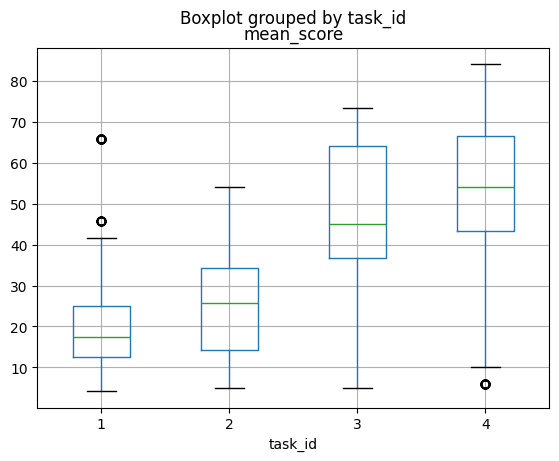

In [37]:
# Box plot of mean NASA RTX scores by task on the same plot
plt.figure(figsize=(10, 6))
features_df.boxplot(column='mean_score', by='task_id')


In [8]:
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, validation_curve
from sklearn import svm, pipeline

features_df_transformed['labels'] = features_df_transformed['cl_class'].map({'low': 0, 'medium': 1, 'high': 2})

X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values

scaler = preprocessing.StandardScaler()
# scaler = preprocessing.MinMaxScaler()
scaler.fit(X)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_x)}, Test set size: {len(test_x)}")

Training set size: 5036, Test set size: 1259


Text(0.5, 0, 'Subject ID')

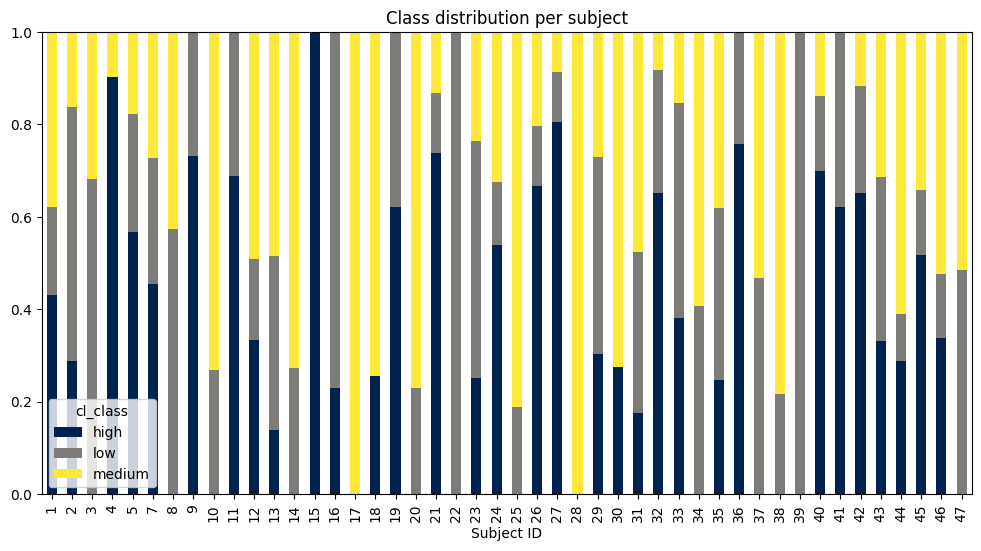

In [118]:
# Let's look at the distribution of classes within subjects
class_distribution = features_df_transformed.groupby('subject_id')['cl_class'].value_counts(normalize=True).unstack(fill_value=0)
class_distribution.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='cividis')
plt.title("Class distribution per subject")
plt.xlabel("Subject ID")

### Building a reusable pipeline ;)

Since we are testing some overlapping windows, we have to be carefull here with possible data leakgae from training to test sets!

1. Outer loop --> Uses *GroupKFold* (by subjects) for testing performances
2. Inner loop --> Uses *GroupKFold* (by subjects_taks) for validation and hyperparams testing

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut, cross_validate


def find_best_model_groups(model, param_grid, X, y, subject_ids, task_ids):
    # Build the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

    # Initialize groupkfold validation
    inner_cv = GroupKFold(n_splits=5)

    inner_groups = [f"{subj}_{task}" for subj, task in zip(subject_ids, task_ids)]

    # Grid Search for hyperparameter tuning
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )

    # LOSO
    outer_cv = GroupKFold(n_splits=5)

    results = cross_validate(
        grid,
        X,
        y,
        groups=subject_ids,
        cv=outer_cv,
        scoring='balanced_accuracy',
        return_estimator=True,
        return_train_score=True,
        params={"groups": inner_groups}
    )

    return results


def find_best_model_independent(model, param_grid, X, y):
    # Build the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

    inner_cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

    # Grid Search for hyperparameter tuning
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )

    outer_cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

    results = cross_validate(
        grid,
        X,
        y,
        cv=outer_cv,
        scoring='balanced_accuracy',
        return_estimator=True,
        return_train_score=True,
    )

    return results

In [98]:
def get_oof_predictions(results, X, y, subject_ids):
    """Reconstruct out-of-fold predictions from cross_validate results."""
    outer_cv = GroupKFold(n_splits=5)
    y_pred = np.empty_like(y)

    for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=subject_ids)):
        estimator = results['estimator'][i].best_estimator_
        y_pred[test_idx] = estimator.predict(X[test_idx])

    return y_pred

### A. Linear SVC

In [96]:
X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values
subject_ids = features_df_transformed['subject_id'].values
task_ids = features_df_transformed['task_id'].values

results = find_best_model_groups(svm.LinearSVC(), {
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}, X, y, subject_ids, task_ids)
# results = find_best_model_independent(svm.LinearSVC(), {
#     'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
# }, X, y)
print("Best hyperparameters for each fold:")
for i, estimator in enumerate(results['estimator']):
    best_params = estimator.best_params_
    print(f"Fold {i+1}: {best_params}")

print("Mean training score:", np.mean(results['train_score']))
print("Mean test score:", np.mean(results['test_score']))

Best hyperparameters for each fold:
Fold 1: {'clf__C': 1.0}
Fold 2: {'clf__C': 0.001}
Fold 3: {'clf__C': 0.001}
Fold 4: {'clf__C': 0.01}
Fold 5: {'clf__C': 0.001}
Mean training score: 0.5538421159466458
Mean test score: 0.44002028501716745


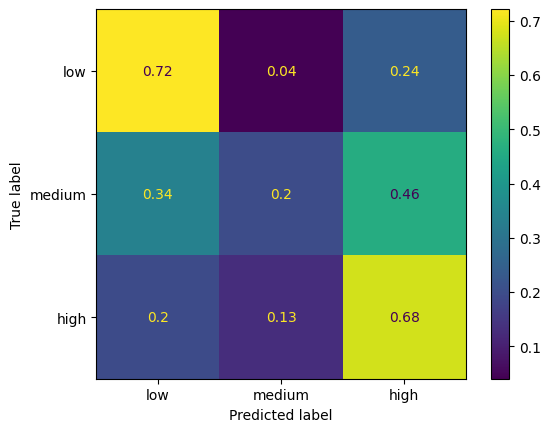

In [100]:
# Lets show the confusion matrix for the 3 classes (on validation set)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Find the best estimator (the one with the highest test score)
y_pred = get_oof_predictions(results, X, y, subject_ids)

_, X_test, _, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
y_pred = results['estimator'][0].best_estimator_.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['low', 'medium', 'high'], normalize='true')

### B. Random Forest Classifier

In [103]:
from sklearn.ensemble import RandomForestClassifier

grid_params =  {
    'clf__n_estimators': [10, 100, 300],
    'clf__min_samples_leaf': [5, 20],
}
# Random Forest
rf_results = find_best_model_groups(
    RandomForestClassifier(class_weight='balanced', random_state=42, max_features='log2'),
    grid_params, X, y, subject_ids, task_ids
)

# rf_results = find_best_model_independent(
#     RandomForestClassifier(class_weight='balanced', random_state=42, max_features='log2'),
#     {
#         'clf__n_estimators': [10, 100, 300],
#         'clf__min_samples_leaf': [5, 20],
#     },
#     X, y)

y_pred_rf = get_oof_predictions(rf_results, X, y, subject_ids)

print("Mean training score:", np.mean(rf_results['train_score']))
print("Mean test score:", np.mean(rf_results['test_score']))

Mean training score: 0.8665115706359263
Mean test score: 0.4602199306606596


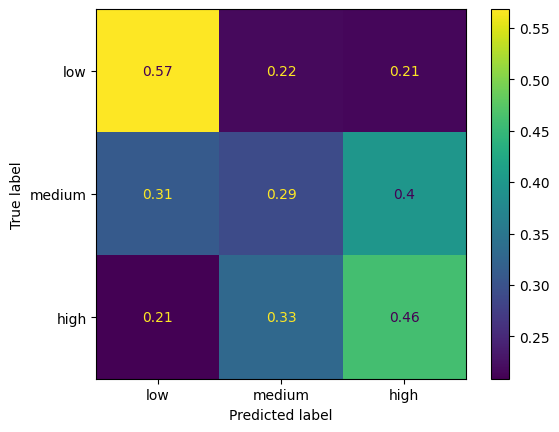

In [104]:
disp = ConfusionMatrixDisplay.from_predictions(y, y_pred_rf, display_labels=['low', 'medium', 'high'], normalize='true')

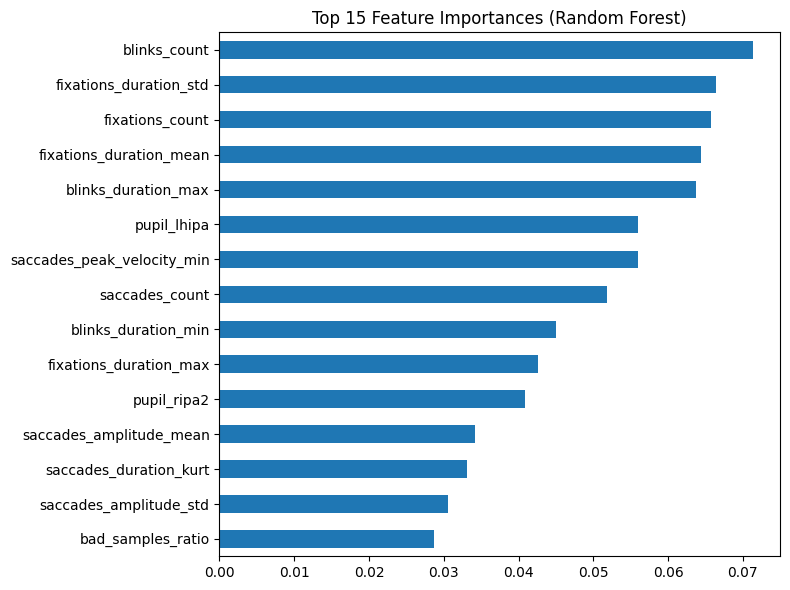

In [65]:
# From the best fold estimator
best_fold = np.argmax(rf_results['test_score'])
best_rf = rf_results['estimator'][best_fold].best_estimator_.named_steps['clf']

importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=True).tail(15).plot.barh(figsize=(8, 6))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [66]:
for i, estimator in enumerate(rf_results['estimator']):
    print(f"Fold {i+1}: {estimator.best_params_}")

Fold 1: {'clf__min_samples_leaf': 20, 'clf__n_estimators': 100}
Fold 2: {'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Fold 3: {'clf__min_samples_leaf': 20, 'clf__n_estimators': 300}
Fold 4: {'clf__min_samples_leaf': 20, 'clf__n_estimators': 300}
Fold 5: {'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}


### C. HGBC

In [105]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgbc_results = find_best_model_groups(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=42, learning_rate=0.01),
    {
        'clf__max_depth': [3, 5],
        'clf__max_iter': [100, 300],
        'clf__min_samples_leaf': [10, 50],
    },
    X, y, subject_ids, task_ids
)

# hgbc_results = find_best_model_independent(
#     HistGradientBoostingClassifier(class_weight='balanced', random_state=42, learning_rate=0.01),
#     {
#         'clf__max_depth': [3, 5],
#         'clf__max_iter': [100, 300],
#         'clf__min_samples_leaf': [10, 50],
#     },
#     X, y
# )

y_pred_hgbc = get_oof_predictions(hgbc_results, X, y, subject_ids)
print(f"Train score: {np.mean(hgbc_results['train_score']):.2f}, Test score: {np.mean(hgbc_results['test_score']):.3f}")
print(f"Test score: {np.mean(hgbc_results['test_score']):.2f} (+/- {np.std(hgbc_results['test_score']):.3f})")


Train score: 0.73, Test score: 0.461
Test score: 0.46 (+/- 0.053)


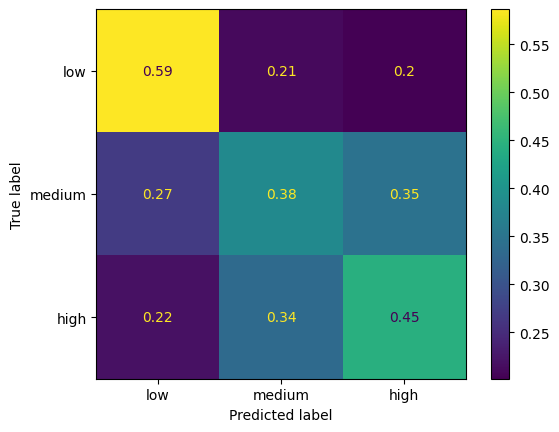

In [43]:
# On the test data (confusion matrix)
disp = ConfusionMatrixDisplay.from_predictions(y, y_pred_hgbc, display_labels=['low', 'medium', 'high'], normalize='true')

In [ ]:
# Print the best paramseters for each fold
for i, estimator in enumerate(hgbc_results['estimator']):
    print(f"Fold {i+1}: {estimator.best_params_}")

# lr: 0.01, max_depth: 3, max_iter: 300, min_samples_leaf: 10

Fold 1: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_iter': 500, 'clf__min_samples_leaf': 50}
Fold 2: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_iter': 300, 'clf__min_samples_leaf': 10}
Fold 3: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_iter': 300, 'clf__min_samples_leaf': 50}
Fold 4: {'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__max_iter': 100, 'clf__min_samples_leaf': 10}
Fold 5: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_iter': 300, 'clf__min_samples_leaf': 50}
Fold 6: {'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__max_iter': 300, 'clf__min_samples_leaf': 10}
Fold 7: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_iter': 300, 'clf__min_samples_leaf': 50}
Fold 8: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__max_iter': 100, 'clf__min_samples_leaf': 50}
Fold 9: {'clf__learning_rate': 0.05, 'clf__max_depth': 8, 'clf__max_iter': 500, 'clf__min_samples_leaf': 10}
Fold 10: {'clf__lea

### D. nuSVC

In [86]:
from sklearn.svm import NuSVC

# nusvc_results = find_best_model_groups(
#     NuSVC(class_weight='balanced', random_state=42),
#     {
#         'clf__nu': [0.01, 0.05, 0.1, 0.5],
#         'clf__kernel': ['rbf', 'linear', 'poly'],
#         'clf__gamma': ['scale', 'auto']
#     },
#     X, y, subject_ids, task_ids
# )

nusvc_results = find_best_model_independent(
    NuSVC(class_weight='balanced', random_state=42, gamma='scale', kernel='rbf'),
    {
        'clf__nu': [0.01, 0.05, 0.1, 0.5, 0.75],
    },
    X, y
)

# y_pred_nusvc = get_oof_predictions(nusvc_results, X, y, subject_ids)
print(f"Train score: {np.mean(nusvc_results['train_score']):.2f} (+/- {np.std(nusvc_results['train_score']):.3f})")
print(f"Test score: {np.mean(nusvc_results['test_score']):.2f} (+/- {np.std(nusvc_results['test_score']):.3f})")

Train score: 0.63 (+/- 0.005)
Test score: 0.44 (+/- 0.020)


In [48]:
outer_cv = GroupKFold(n_splits=10)
for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=subject_ids)):
    test_subjects = np.unique(subject_ids[test_idx])
    print(f"Fold {i+1} | Subjects: {test_subjects} | "
          f"Train: {results['train_score'][i]:.3f} | "
          f"Test: {results['test_score'][i]:.3f}")

Fold 1 | Subjects: [14 19 31 36] | Train: 0.537 | Test: 0.501
Fold 2 | Subjects: [ 2 33 41 42] | Train: 0.569 | Test: 0.311
Fold 3 | Subjects: [ 9 17 22 32] | Train: 0.547 | Test: 0.460
Fold 4 | Subjects: [ 1  3 21 35 37] | Train: 0.564 | Test: 0.453
Fold 5 | Subjects: [ 5 18 25 34 44] | Train: 0.525 | Test: 0.561
Fold 6 | Subjects: [ 7 10 20 39 40] | Train: 0.546 | Test: 0.570
Fold 7 | Subjects: [12 29 30 38] | Train: 0.526 | Test: 0.523
Fold 8 | Subjects: [11 13 16 23 43] | Train: 0.557 | Test: 0.488
Fold 9 | Subjects: [ 8 27 28 45 46] | Train: 0.566 | Test: 0.383
Fold 10 | Subjects: [ 4 15 24 26 47] | Train: 0.537 | Test: 0.486


In [69]:
for i, estimator in enumerate(nusvc_results['estimator']):
    print(f"Fold {i+1}: {estimator.best_params_}")


Fold 1: {'clf__gamma': 'scale', 'clf__kernel': 'poly', 'clf__nu': 0.5}
Fold 2: {'clf__gamma': 'scale', 'clf__kernel': 'poly', 'clf__nu': 0.5}
Fold 3: {'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.5}
Fold 4: {'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.5}
Fold 5: {'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.5}
Fold 6: {'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.5}
Fold 7: {'clf__gamma': 'scale', 'clf__kernel': 'poly', 'clf__nu': 0.5}
Fold 8: {'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.5}
Fold 9: {'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.5}
Fold 10: {'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.5}


### E. kNN

## Deep learning models

### TabNet

In [9]:
# Splitting the data into training, validation and testing
from sklearn.model_selection import train_test_split

X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values

# All feautres are numerical

train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.25, random_state=42) 

X_train, y_train = X[train_idx], y[train_idx]
X_valid, y_valid = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [16]:
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer

import torch

# --- Step 1: Unsupervised pretraining on all available features ---
unsupervised_model = TabNetPretrainer(
    n_d=8, n_a=8, n_steps=3,
    gamma=1.0, n_independent=1, n_shared=2,
    cat_idxs=[],
    cat_dims=[],
    cat_emb_dim=1,
    lambda_sparse=1e-2, momentum=0.02, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"gamma": 0.95, "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="entmax",
)

# Pretrain using ALL available data (train + valid + test features, no labels needed)
X_pretrain = np.concatenate([X_train, X_valid, X_test], axis=0)

unsupervised_model.fit(
    X_train=X_pretrain,
    eval_set=[X_valid],
    max_epochs=200, patience=30,
    batch_size=256, virtual_batch_size=128,
    pretraining_ratio=0.8,  # fraction of features to mask
)

c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1686.20811| val_0_unsup_loss_numpy: 3059.374755859375|  0:00:02s
epoch 1  | loss: 25.76395| val_0_unsup_loss_numpy: 99.86255645751953|  0:00:04s
epoch 2  | loss: 9.91351 | val_0_unsup_loss_numpy: 16.87822914123535|  0:00:06s
epoch 3  | loss: 5.43982 | val_0_unsup_loss_numpy: 7.225940227508545|  0:00:09s
epoch 4  | loss: 3.89477 | val_0_unsup_loss_numpy: 3.5309898853302|  0:00:11s
epoch 5  | loss: 3.30476 | val_0_unsup_loss_numpy: 3.0955400466918945|  0:00:14s
epoch 6  | loss: 2.90033 | val_0_unsup_loss_numpy: 2.7084500789642334|  0:00:16s
epoch 7  | loss: 2.55534 | val_0_unsup_loss_numpy: 2.511399984359741|  0:00:18s
epoch 8  | loss: 2.47427 | val_0_unsup_loss_numpy: 2.329469919204712|  0:00:20s
epoch 9  | loss: 2.27407 | val_0_unsup_loss_numpy: 2.455859899520874|  0:00:23s
epoch 10 | loss: 2.19681 | val_0_unsup_loss_numpy: 2.258229970932007|  0:00:25s
epoch 11 | loss: 2.10453 | val_0_unsup_loss_numpy: 1.8608200550079346|  0:00:27s
epoch 12 | loss: 2.01554 | val_0_unsu

c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [38]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

# --- Step 2: Supervised classifier initialized from pretrained weights ---
clf = TabNetClassifier(
    n_d=8, n_a=8, n_steps=3,
    gamma=1.0, n_independent=1, n_shared=2,
    cat_idxs=[],
    cat_dims=[],
    cat_emb_dim=1,
    lambda_sparse=1e-2, momentum=0.02, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"gamma": 0.95, "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15
)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    max_epochs=200, patience=40,
    batch_size=256, virtual_batch_size=128,
    augmentations=aug,
    from_unsupervised=unsupervised_model,  # load pretrained weights
)

c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")
c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\abstract_model.py:118: UserWarning: Pretraining: mask_type changed from sparsemax to entmax
  warnings.warn(wrn_msg)
c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 1.29213 | train_accuracy: 0.4583  | valid_accuracy: 0.45909 |  0:00:01s
epoch 1  | loss: 1.04866 | train_accuracy: 0.46757 | valid_accuracy: 0.45353 |  0:00:03s
epoch 2  | loss: 0.98711 | train_accuracy: 0.42044 | valid_accuracy: 0.4162  |  0:00:04s
epoch 3  | loss: 0.98503 | train_accuracy: 0.41461 | valid_accuracy: 0.38125 |  0:00:06s
epoch 4  | loss: 0.95808 | train_accuracy: 0.43685 | valid_accuracy: 0.4162  |  0:00:08s
epoch 5  | loss: 0.94183 | train_accuracy: 0.44877 | valid_accuracy: 0.42335 |  0:00:09s
epoch 6  | loss: 0.93034 | train_accuracy: 0.50357 | valid_accuracy: 0.45671 |  0:00:11s
epoch 7  | loss: 0.91314 | train_accuracy: 0.52476 | valid_accuracy: 0.47975 |  0:00:13s
epoch 8  | loss: 0.89723 | train_accuracy: 0.52899 | valid_accuracy: 0.47816 |  0:00:14s
epoch 9  | loss: 0.8991  | train_accuracy: 0.55255 | valid_accuracy: 0.49404 |  0:00:16s
epoch 10 | loss: 0.89605 | train_accuracy: 0.56447 | valid_accuracy: 0.52343 |  0:00:17s
epoch 11 | loss: 0.88

c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Test Accuracy: 0.746


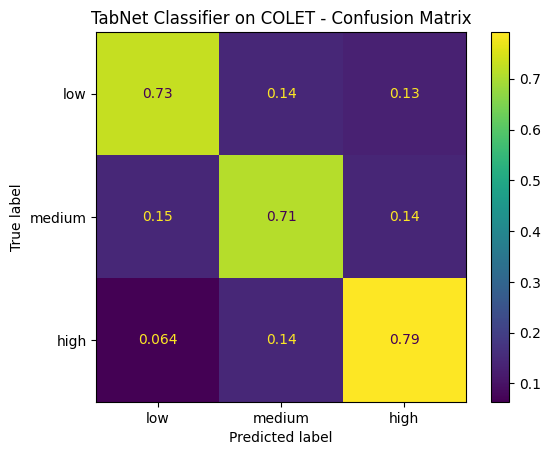

In [75]:
# Testing accuracy
y_pred = clf.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['low', 'medium', 'high'], normalize='true')
plt.title("TabNet Classifier on COLET - Confusion Matrix")

print(f"Test Accuracy: {(y_pred == y_test).mean():.3f}")

In [19]:
# Check how well each feature separates subjects vs. classes
from sklearn.feature_selection import mutual_info_classif

# MI with cognitive load class (what we want)
mi_class = mutual_info_classif(X, y, random_state=42)

# MI with subject identity (what we DON'T want)
subject_ids = features_df_transformed['subject_id'].values
mi_subject = mutual_info_classif(X, subject_ids, random_state=42)

mi_df = pd.DataFrame({
    'feature': feature_cols,
    'MI_class': mi_class,
    'MI_subject': mi_subject,
    'ratio': mi_class / (mi_subject + 1e-8)
})

# Keep features with high class MI and low subject MI
mi_df.sort_values('ratio', ascending=False).head(30)

,feature,MI_class,MI_subject,ratio
8,saccades_peak_velocity_min,0.882332,3.010558,0.293079
13,saccades_amplitude_max,0.839008,2.885083,0.290809
14,saccades_amplitude_min,0.676156,2.368534,0.285475
7,saccades_count,0.077783,0.272472,0.285470
9,saccades_peak_velocity_max,0.853193,3.018262,0.282677
0,fixations_count,0.075542,0.269709,0.280088
1,fixations_duration_mean,0.080184,0.337366,0.237676
27,pupil_lhipa,0.044050,0.200445,0.219763
26,blinks_duration_min,0.062875,0.356684,0.176276
24,blinks_count,0.065719,0.389072,0.168911


TEMP :: Testing with my custom data

In [55]:
import tqdm
reload(cwfeat)

NBACK_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "NBACK"
TASKS = [1,2,3]
TRIALS = [1,2,3,4]
SUBJECT_EXCLUSION = ["ERK0"]

# First, extract all subjects UID (folder names under NBACK_DATASET_DIR)
subject_uids = [d.name for d in NBACK_DATASET_DIR.iterdir() if d.is_dir()]
subject_uids = [subject_id for subject_id in subject_uids if subject_id not in SUBJECT_EXCLUSION]

# Then, for each subject, load their data
all_eye_df = cwpre.load_nback_dataset(NBACK_DATASET_DIR, subject_uids, TASKS, TRIALS)

all_eye_data_grouped = all_eye_df.groupby(['subject_id', 'task_id', 'trial_id'])
# Extract all window features
Fs = 60
WINDOW_N = 600 # 10 seconds at 60Hz
WINDOW_STEP = 60
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

skipped_windows = None
skip_window_counter = 0

nback_features_df = pd.DataFrame()
for (subject_id, task_id, trial_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_nback_data(window_df, verbose=False)
        if window_preprocess_df['low_confidence_percentage'].iloc[0] > 30:
            t_start = window_preprocess_df['timestamp_sec'].min()
            t_end = window_preprocess_df['timestamp_sec'].max()
            #print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {window_preprocess_df['low_confidence_percentage'].iloc[0]:.2f}%")
            skip_window_counter += 1
            window_preprocess_df['skip_id'] = skip_window_counter
            skipped_windows = pd.concat([skipped_windows, window_preprocess_df], ignore_index=True) if skipped_windows is not None else window_preprocess_df
            continue

        # Extract features
        try:
            features = cwfeat.extract_window_features(
                window_preprocess_df, 
                window_gaze_df, 
                window_pupil_df, 
                window_gaps_df, 
                ivt_threshold=20, 
                min_fixation_duration=55, 
                verbose=False
            )
        except Exception as e:
            print(f"Error extracting features for window in subject {subject_id}, task {task_id}: {e}")
            continue
        features['bad_samples_ratio'] = window_preprocess_df['low_confidence_percentage'].mean()
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['trial_id'] = trial_id
        features['nback_level'] = window_preprocess_df['nback_level'].iloc[0]
        feature_rows.append(features)
    
    nback_features_df = pd.concat([nback_features_df, pd.DataFrame(feature_rows)], ignore_index=True)
    # if subject_id > 5:
    #     break

print(f"Extracted features for {len(nback_features_df)} windows.")
print(f"Skipped {skip_window_counter} windows due to low confidence percentage.")

Loading subjects:  12%|█▎        | 1/8 [00:00<00:01,  5.31it/s]

Loading subjects:  25%|██▌       | 2/8 [00:00<00:01,  3.93it/s]

Loading subjects:  38%|███▊      | 3/8 [00:00<00:01,  3.59it/s]

Loading subjects:  50%|█████     | 4/8 [00:01<00:01,  3.76it/s]

Loading subjects:  62%|██████▎   | 5/8 [00:01<00:00,  3.15it/s]

Loading subjects:  75%|███████▌  | 6/8 [00:01<00:00,  2.69it/s]

Extracting features: 100%|██████████| 96/96 [09:28<00:00,  5.93s/it]

Extracted features for 3993 windows.
Skipped 12 windows due to low confidence percentage.


In [ ]:
nback_features_df_transformed = nback_features_df.copy()
nback_features_df_transformed.dropna( inplace=True) # Drop rows with NaNs for now

# Apply thresholding to the mean NASA RTX score for classes
nback_features_df_transformed["cl_class"] = nback_features_df_transformed["nback_level"].apply(lambda x: "high" if x == 2 else ("low" if x == 0 else "medium"))
feature_cols = [col for col in nback_features_df_transformed.columns if col not in ['subject_id', 'task_id', 'cl_class', 'trial_id', 'nback_level']]

X_nback = nback_features_df_transformed[feature_cols].values
y_nback = nback_features_df_transformed['nback_level'].values

nback_features_df_transformed.describe()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2,bad_samples_ratio,task_id,trial_id,nback_level
count,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,...,3.842000e+03,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000,3842.000000
mean,15.559604,685.003068,2136.480482,119.241265,1.508275,2.672902,637.646251,14.775898,24.769450,145.911670,...,5.081001e+01,1.874545,120.705307,95.955432,4.515299,0.000037,2.966901,2.019261,2.487246,0.996616
std,6.611447,400.224474,1224.167034,108.237342,0.831986,3.664561,462.606569,6.713500,5.110978,103.318123,...,4.803324e+01,2.046169,97.836716,78.632745,0.368219,0.000036,3.800417,0.816163,1.117175,0.816543
min,4.000000,138.048437,266.720000,50.010000,-1.639353,-5.447431,61.019976,4.000000,20.003296,26.256501,...,1.945901e-12,0.000000,0.000000,0.000000,3.104554,0.000001,0.000000,1.000000,1.000000,0.000000
25%,10.000000,398.413000,1233.580000,50.010000,0.954318,0.007680,312.287695,9.000000,21.645551,81.955718,...,2.144411e+01,0.000000,0.000000,0.000000,4.299764,0.000014,0.000000,1.000000,1.000000,0.000000
50%,15.000000,575.670667,1833.700000,83.350000,1.450049,1.698692,497.899309,14.000000,23.245029,114.807619,...,3.345556e+01,1.000000,150.030000,116.690000,4.514147,0.000024,1.666667,2.000000,2.000000,1.000000
75%,20.000000,870.174000,2683.870000,133.360000,2.027036,4.402037,808.536286,19.000000,26.159720,161.973816,...,6.536618e+01,3.000000,200.040000,150.030000,4.802106,0.000046,4.333333,3.000000,3.000000,2.000000
max,36.000000,2433.820000,8401.680000,1883.710000,4.416898,21.858591,3338.841897,35.000000,130.139912,906.076246,...,7.160472e+02,9.000000,300.000000,283.390000,5.617606,0.000423,27.833333,3.000000,4.000000,2.000000


<Axes: xlabel='nback_level'>

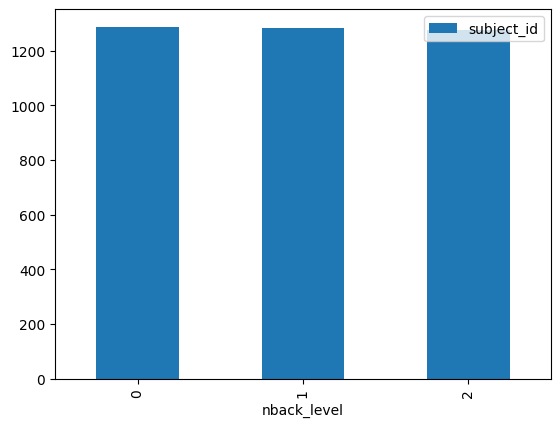

In [70]:
nback_features_df_transformed.groupby('nback_level').count().plot(kind='bar', y='subject_id')

NBACK test data accuracy: 0.375


Text(0.5, 1.0, 'TabNet Classifier on NBACK - Confusion Matrix')

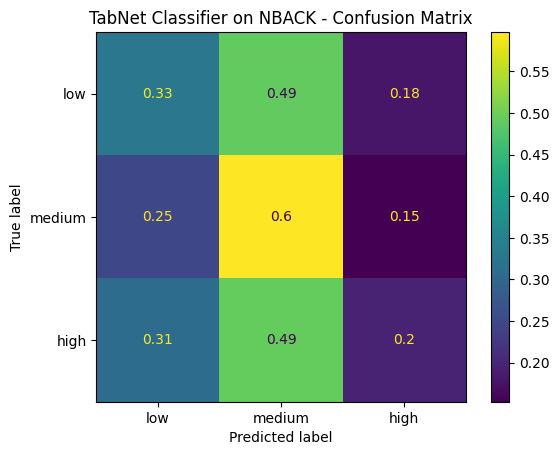

In [77]:
y_nback_predict = clf.predict(X_nback)

print(f"NBACK test data accuracy: {(y_nback_predict == y_nback).mean():.3f}")

disp = ConfusionMatrixDisplay.from_predictions(y_nback, y_nback_predict, display_labels=['low', 'medium', 'high'], normalize='true')
plt.title("TabNet Classifier on NBACK - Confusion Matrix")


Fine tune on NBack

In [78]:
X = nback_features_df_transformed[feature_cols].values
y = nback_features_df_transformed['nback_level'].values

# All feautres are numerical

train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.25, random_state=42) 

X_train_nback, y_train_nback = X[train_idx], y[train_idx]
X_valid_nback, y_valid_nback = X[val_idx], y[val_idx]
X_test_nback, y_test_nback = X[test_idx], y[test_idx]

clf_nback = TabNetClassifier(
    n_d=8, n_a=8, n_steps=3,
    gamma=1.0, n_independent=1, n_shared=2,
    cat_idxs=[],
    cat_dims=[],
    cat_emb_dim=1,
    lambda_sparse=1e-2, momentum=0.02, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"gamma": 0.95, "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15
)

clf_nback.fit(
    X_train=X_train_nback, y_train=y_train_nback,
    eval_set=[(X_train_nback, y_train_nback), (X_valid_nback, y_valid_nback)],
    eval_name=['train', 'valid'],
    max_epochs=200, patience=40,
    batch_size=256, virtual_batch_size=128,
    augmentations=aug,
    from_unsupervised=unsupervised_model,  # load pretrained weights
)

c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")
c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\abstract_model.py:118: UserWarning: Pretraining: mask_type changed from sparsemax to entmax
  warnings.warn(wrn_msg)
c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 1.44077 | train_accuracy: 0.36024 | valid_accuracy: 0.36801 |  0:00:01s
epoch 1  | loss: 1.16538 | train_accuracy: 0.36979 | valid_accuracy: 0.36801 |  0:00:02s
epoch 2  | loss: 1.09402 | train_accuracy: 0.37934 | valid_accuracy: 0.37451 |  0:00:03s
epoch 3  | loss: 1.06391 | train_accuracy: 0.36719 | valid_accuracy: 0.35891 |  0:00:04s
epoch 4  | loss: 1.05226 | train_accuracy: 0.38976 | valid_accuracy: 0.38882 |  0:00:05s
epoch 5  | loss: 1.03367 | train_accuracy: 0.40538 | valid_accuracy: 0.41612 |  0:00:06s
epoch 6  | loss: 1.01133 | train_accuracy: 0.40799 | valid_accuracy: 0.41092 |  0:00:07s
epoch 7  | loss: 1.00863 | train_accuracy: 0.43273 | valid_accuracy: 0.40572 |  0:00:08s
epoch 8  | loss: 1.00616 | train_accuracy: 0.41189 | valid_accuracy: 0.41222 |  0:00:09s
epoch 9  | loss: 0.9893  | train_accuracy: 0.46745 | valid_accuracy: 0.44213 |  0:00:10s
epoch 10 | loss: 0.98341 | train_accuracy: 0.47396 | valid_accuracy: 0.42913 |  0:00:11s
epoch 11 | loss: 0.97

c:\Users\alexa\anaconda3\envs\master-thesis\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


NBACK test data accuracy: 0.661


Text(0.5, 1.0, 'TabNet Fine-tuned on NBACK - Confusion Matrix')

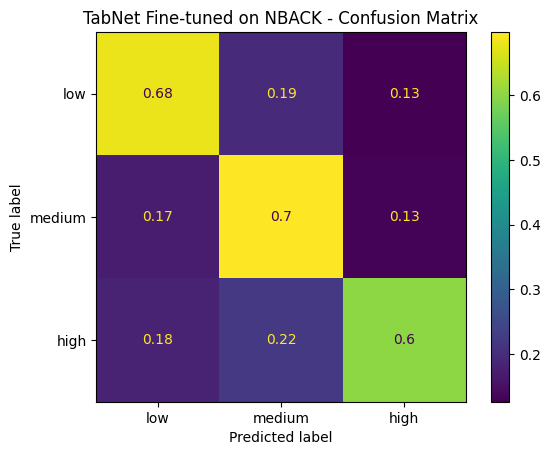

In [79]:
y_nback_predict = clf_nback.predict(X_test_nback)

print(f"NBACK test data accuracy: {(y_nback_predict == y_test_nback).mean():.3f}")

disp = ConfusionMatrixDisplay.from_predictions(y_test_nback, y_nback_predict, display_labels=['low', 'medium', 'high'], normalize='true')
plt.title("TabNet Fine-tuned on NBACK - Confusion Matrix")